#  LAB 5 - ANÁLISIS DE TRÁFICO
### Michelle Angel de María Mejía Villela

In [3]:
from scapy.all import rdpcap, IP, TCP, UDP, Raw
import pandas as pd

# --------------------------------------------
# 1. Cargar el archivo pcap
# --------------------------------------------
pcap_file = "data/analisis_paquetes.pcap"   # cambia la ruta si está en otra carpeta
packets = rdpcap(pcap_file)

print("Tipo de dato de packets:", type(packets))
print("Cantidad total de paquetes:", len(packets))
print()


# --------------------------------------------
# 2. Mostrar 10 paquetes de prueba
#    Tipo, longitud y contenido/resumen
# --------------------------------------------
print("=== PRIMEROS 10 PAQUETES ===")
for i, pkt in enumerate(packets[:10], start=1):
    print(f"\nPaquete #{i}")
    print("Tipo:", type(pkt))
    print("Longitud:", len(pkt))
    print("Resumen:", pkt.summary())
    print("Contenido:")
    pkt.show()
    print("-" * 60)


# --------------------------------------------
# 3. Extraer columnas principales del pcap
#    Src Address, Dst Address, Src Port, Dst Port
# --------------------------------------------
data = []

for pkt in packets:
    src_ip = None
    dst_ip = None
    src_port = None
    dst_port = None
    payload = b""
    payload_len = 0
    pkt_len = len(pkt)

    # Verificar si tiene capa IP
    if IP in pkt:
        src_ip = pkt[IP].src
        dst_ip = pkt[IP].dst

    # Verificar si tiene capa TCP
    if TCP in pkt:
        src_port = pkt[TCP].sport
        dst_port = pkt[TCP].dport

        # Si tiene datos en bruto
        if Raw in pkt:
            payload = bytes(pkt[Raw].load)
            payload_len = len(payload)

    # Verificar si tiene capa UDP
    elif UDP in pkt:
        src_port = pkt[UDP].sport
        dst_port = pkt[UDP].dport

        if Raw in pkt:
            payload = bytes(pkt[Raw].load)
            payload_len = len(payload)

    # Guardar fila
    data.append({
        "src_ip": src_ip,
        "dst_ip": dst_ip,
        "src_port": src_port,
        "dst_port": dst_port,
        "payload": payload,
        "payload_len": payload_len,
        "pkt_len": pkt_len
    })


# --------------------------------------------
# 4. Crear DataFrame
# --------------------------------------------
df = pd.DataFrame(data)

print("\n=== DATAFRAME BASE ===")
print(df.head(10))

print("\n=== INFO GENERAL ===")
print(df.info())

print("\n=== COLUMNAS PEDIDAS EN EL TESTEO ===")
print(df[["src_ip", "dst_ip", "src_port", "dst_port"]].head(10))

Tipo de dato de packets: <class 'scapy.plist.PacketList'>
Cantidad total de paquetes: 62

=== PRIMEROS 10 PAQUETES ===

Paquete #1
Tipo: <class 'scapy.layers.l2.Ether'>
Longitud: 975
Resumen: Ether / IP / UDP / DNS Qry b'google.com.' / Raw
Contenido:
###[ Ethernet ]###
  dst       = 80:37:73:96:9b:db
  src       = 88:e9:fe:6a:92:52
  type      = IPv4
###[ IP ]###
     version   = 4
     ihl       = 5
     tos       = 0x0
     len       = 961
     id        = 1
     flags     = 
     frag      = 0
     ttl       = 64
     proto     = udp
     chksum    = 0x52e6
     src       = 10.1.10.53
     dst       = 84.54.22.33
     \options   \
###[ UDP ]###
        sport     = domain
        dport     = domain
        len       = 941
        chksum    = 0xf60e
###[ DNS ]###
           id        = 12
           qr        = 0
           opcode    = QUERY
           aa        = 0
           tc        = 0
           rd        = 1
           ra        = 0
           z         = 0
           ad       

In [4]:
# ============================================
# 5. ESTADÍSTICAS BÁSICAS
# ============================================

print("=== ESTADÍSTICAS BÁSICAS ===\n")

# a) IP origen más frecuente
ip_origen_mas_frecuente = df["src_ip"].value_counts().idxmax()
conteo_ip_origen = df["src_ip"].value_counts().max()

print("a) IP origen más frecuente:")
print(ip_origen_mas_frecuente, "->", conteo_ip_origen, "paquetes\n")


# b) IP destino más frecuente
ip_destino_mas_frecuente = df["dst_ip"].value_counts().idxmax()
conteo_ip_destino = df["dst_ip"].value_counts().max()

print("b) IP destino más frecuente:")
print(ip_destino_mas_frecuente, "->", conteo_ip_destino, "paquetes\n")


# c) ¿A qué IPs se comunica la IP del inciso a?
ips_con_las_que_se_comunica = df[df["src_ip"] == ip_origen_mas_frecuente]["dst_ip"].value_counts()

print("c) IPs con las que se comunica la IP origen más frecuente:")
print(ips_con_las_que_se_comunica)
print()


# d) ¿A qué puertos destino se comunica la IP del inciso a?
puertos_destino_ip_origen = df[df["src_ip"] == ip_origen_mas_frecuente]["dst_port"].value_counts()

print("d) Puertos destino a los que se comunica la IP origen más frecuente:")
print(puertos_destino_ip_origen)
print()


# e) ¿A qué puertos origen se comunica la IP del inciso b?
puertos_origen_ip_destino = df[df["dst_ip"] == ip_destino_mas_frecuente]["src_port"].value_counts()

print("e) Puertos origen con los que se comunica la IP destino más frecuente:")
print(puertos_origen_ip_destino)
print()


# f) Propósito de los puertos más frecuentes de d y e
def explicar_puerto(puerto):
    puertos_comunes = {
        20: "FTP-DATA, transferencia de archivos",
        21: "FTP, control de transferencia de archivos",
        22: "SSH, acceso remoto seguro",
        23: "Telnet, acceso remoto sin cifrar",
        25: "SMTP, envío de correo",
        53: "DNS, resolución de nombres de dominio",
        67: "DHCP, asignación dinámica de IP (servidor)",
        68: "DHCP, asignación dinámica de IP (cliente)",
        80: "HTTP, tráfico web sin cifrar",
        110: "POP3, recepción de correo",
        123: "NTP, sincronización de tiempo",
        143: "IMAP, acceso a correo",
        161: "SNMP, monitoreo de red",
        443: "HTTPS, tráfico web cifrado",
        445: "SMB, compartición de archivos en red",
        3306: "MySQL, base de datos",
        3389: "RDP, escritorio remoto",
        5432: "PostgreSQL, base de datos"
    }
    return puertos_comunes.get(puerto, "Puerto no identificado en la tabla básica")

# Puerto más frecuente en d
puerto_d_mas_frecuente = puertos_destino_ip_origen.idxmax()
# Puerto más frecuente en e
puerto_e_mas_frecuente = puertos_origen_ip_destino.idxmax()

print("f) Propósito de los puertos más frecuentes:")
print(f"Puerto más frecuente en d: {puerto_d_mas_frecuente} -> {explicar_puerto(puerto_d_mas_frecuente)}")
print(f"Puerto más frecuente en e: {puerto_e_mas_frecuente} -> {explicar_puerto(puerto_e_mas_frecuente)}")

=== ESTADÍSTICAS BÁSICAS ===

a) IP origen más frecuente:
10.1.10.53 -> 31 paquetes

b) IP destino más frecuente:
10.1.10.53 -> 31 paquetes

c) IPs con las que se comunica la IP origen más frecuente:
dst_ip
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64

d) Puertos destino a los que se comunica la IP origen más frecuente:
dst_port
53    31
Name: count, dtype: int64

e) Puertos origen con los que se comunica la IP destino más frecuente:
src_port
53    31
Name: count, dtype: int64

f) Propósito de los puertos más frecuentes:
Puerto más frecuente en d: 53 -> DNS, resolución de nombres de dominio
Puerto más frecuente en e: 53 -> DNS, resolución de nombres de dominio


Media payload: 438.1774193548387
Desviación estándar: 474.458501500068

Paquetes con |Z| > 2:
Empty DataFrame
Columns: [src_ip, dst_ip, payload_len, z_score]
Index: []

Paquetes con |Z| > 3:
Empty DataFrame
Columns: [src_ip, dst_ip, payload_len, z_score]
Index: []


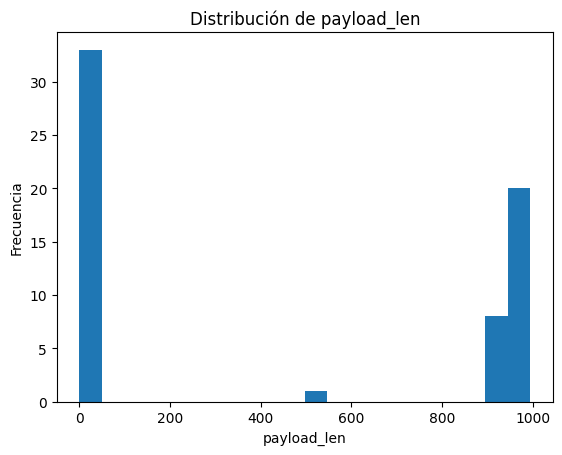

In [5]:
# ============================================
# 6. Z-SCORE SOBRE PAYLOAD
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# calcular media y desviación estándar
media_payload = df["payload_len"].mean()
std_payload = df["payload_len"].std()

print("Media payload:", media_payload)
print("Desviación estándar:", std_payload)

# calcular z-score
df["z_score"] = (df["payload_len"] - media_payload) / std_payload

# ver paquetes con anomalía
anomalias_z2 = df[np.abs(df["z_score"]) > 2]
anomalias_z3 = df[np.abs(df["z_score"]) > 3]

print("\nPaquetes con |Z| > 2:")
print(anomalias_z2[["src_ip","dst_ip","payload_len","z_score"]])

print("\nPaquetes con |Z| > 3:")
print(anomalias_z3[["src_ip","dst_ip","payload_len","z_score"]])


# --------------------------------------------
# Histograma
# --------------------------------------------
plt.figure()
plt.hist(df["payload_len"], bins=20)
plt.title("Distribución de payload_len")
plt.xlabel("payload_len")
plt.ylabel("Frecuencia")

plt.show()

In [6]:
# ============================================
# 7. Z-SCORE CON CONOCIMIENTO DE DOMINIO
# ============================================

media_dns = 50
std_dns = 15

df["z_score_dns"] = (df["payload_len"] - media_dns) / std_dns

anomalias_dns = df[abs(df["z_score_dns"]) > 3]

print("Paquetes detectados como anomalías usando conocimiento DNS:")
print(anomalias_dns[["src_ip","dst_ip","payload_len","z_score_dns"]])

print("\nCantidad de anomalías detectadas:", len(anomalias_dns))

Paquetes detectados como anomalías usando conocimiento DNS:
         src_ip       dst_ip  payload_len  z_score_dns
0    10.1.10.53  84.54.22.33          905    57.000000
1   84.54.22.33   10.1.10.53            0    -3.333333
2    10.1.10.53  84.54.22.33          919    57.933333
3   84.54.22.33   10.1.10.53            0    -3.333333
4    10.1.10.53  84.54.22.33          956    60.400000
..          ...          ...          ...          ...
57  84.54.22.33   10.1.10.53            0    -3.333333
58   10.1.10.53  84.54.22.33          913    57.533333
59  84.54.22.33   10.1.10.53            0    -3.333333
60   10.1.10.53  84.54.22.33          532    32.133333
61  84.54.22.33   10.1.10.53            0    -3.333333

[62 rows x 4 columns]

Cantidad de anomalías detectadas: 62


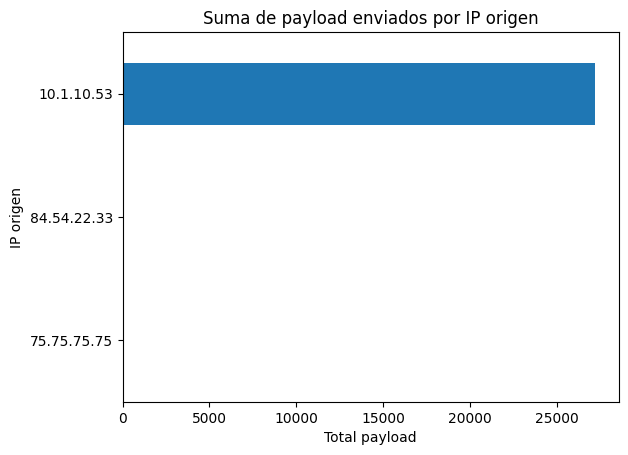

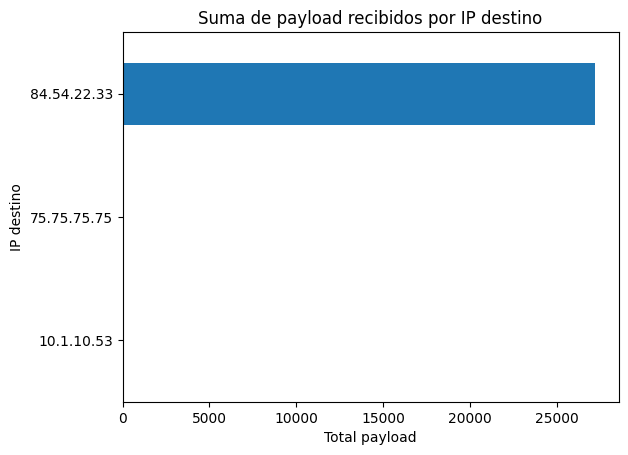

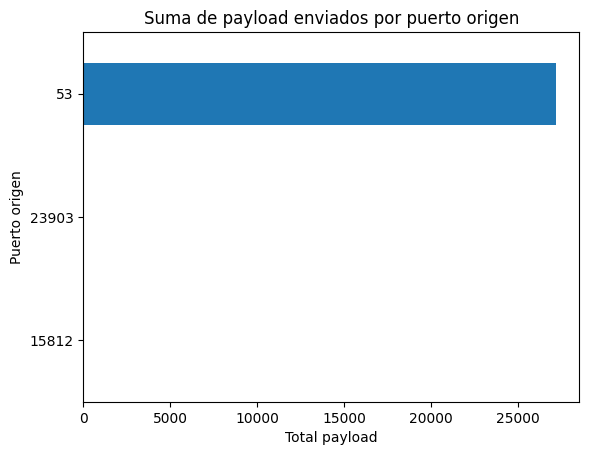

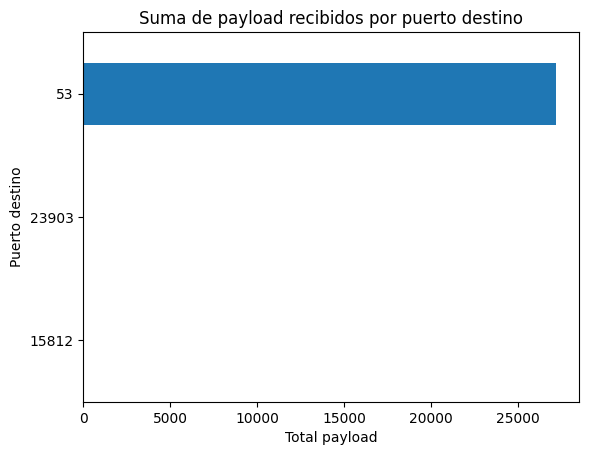

In [7]:
# ============================================
# 8. GRÁFICAS DE PAYLOAD
# ============================================

import matplotlib.pyplot as plt

# a) suma de payload por IP origen
payload_por_ip_origen = df.groupby("src_ip")["payload_len"].sum().sort_values()

plt.figure()
payload_por_ip_origen.plot(kind="barh")
plt.title("Suma de payload enviados por IP origen")
plt.xlabel("Total payload")
plt.ylabel("IP origen")

plt.show()


# b) suma de payload por IP destino
payload_por_ip_destino = df.groupby("dst_ip")["payload_len"].sum().sort_values()

plt.figure()
payload_por_ip_destino.plot(kind="barh")
plt.title("Suma de payload recibidos por IP destino")
plt.xlabel("Total payload")
plt.ylabel("IP destino")

plt.show()


# c) suma de payload por puerto origen
payload_por_puerto_origen = df.groupby("src_port")["payload_len"].sum().sort_values()

plt.figure()
payload_por_puerto_origen.plot(kind="barh")
plt.title("Suma de payload enviados por puerto origen")
plt.xlabel("Total payload")
plt.ylabel("Puerto origen")

plt.show()


# d) suma de payload por puerto destino
payload_por_puerto_destino = df.groupby("dst_port")["payload_len"].sum().sort_values()

plt.figure()
payload_por_puerto_destino.plot(kind="barh")
plt.title("Suma de payload recibidos por puerto destino")
plt.xlabel("Total payload")
plt.ylabel("Puerto destino")

plt.show()

In [8]:
# ============================================
# 9. ISOLATION FOREST
# ============================================

from sklearn.ensemble import IsolationForest

# seleccionar columnas numéricas
X = df[["payload_len", "pkt_len"]]

# modelo
modelo = IsolationForest(
    contamination=0.5,
    random_state=42
)

df["anomalia_if"] = modelo.fit_predict(X)

# convertir resultado
# -1 = anomalía
# 1 = normal

anomalias_if = df[df["anomalia_if"] == -1]

print("Paquetes detectados como anomalías por Isolation Forest:")
print(anomalias_if[["src_ip","dst_ip","payload_len","pkt_len"]])

print("\nCantidad detectada por Isolation Forest:", len(anomalias_if))

Paquetes detectados como anomalías por Isolation Forest:
         src_ip       dst_ip  payload_len  pkt_len
0    10.1.10.53  84.54.22.33          905      975
2    10.1.10.53  84.54.22.33          919      989
4    10.1.10.53  84.54.22.33          956     1026
6    10.1.10.53  84.54.22.33          942     1012
8    10.1.10.53  84.54.22.33          947     1017
10   10.1.10.53  84.54.22.33          989     1059
12   10.1.10.53  84.54.22.33          952     1022
14   10.1.10.53  84.54.22.33          923      993
16   10.1.10.53  84.54.22.33          903      973
18   10.1.10.53  84.54.22.33          936     1006
20   10.1.10.53  84.54.22.33          995     1065
22   10.1.10.53  75.75.75.75            0       79
23   10.1.10.53  75.75.75.75            0       79
24  75.75.75.75   10.1.10.53            0      119
25  75.75.75.75   10.1.10.53            0      131
28   10.1.10.53  84.54.22.33          930     1000
30   10.1.10.53  84.54.22.33          948     1018
32   10.1.10.53  84.54.22

In [9]:
ip_mas_frecuente = ip_origen_mas_frecuente

df_ip_frecuente = df[df["src_ip"] == ip_mas_frecuente]

print(df_ip_frecuente.head())

       src_ip       dst_ip  src_port  dst_port  \
0  10.1.10.53  84.54.22.33        53        53   
2  10.1.10.53  84.54.22.33        53        53   
4  10.1.10.53  84.54.22.33        53        53   
6  10.1.10.53  84.54.22.33        53        53   
8  10.1.10.53  84.54.22.33        53        53   

                                             payload  payload_len  pkt_len  \
0  b'\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\...          905      975   
2  b':\xef\xbf\xbdle:\xc7\xa9\xef\xbf\xbd\xef\xbf...          919      989   
4  b'\xef\xbf\xbd\xef\xbf\xbd^n\xef\xbf\xbd\'\'\x...          956     1026   
6  b'\xe4\x8e\x91Bj_\xef\xbf\xbda\r\xef\xbf\xbd\x...          942     1012   
8  b'\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xcb\xb4...          947     1017   

    z_score  z_score_dns  anomalia_if  
0  0.983906    57.000000           -1  
2  1.013413    57.933333           -1  
4  1.091397    60.400000           -1  
6  1.061890    59.466667           -1  
8  1.072428    59.800000      

In [10]:
agrupado = df_ip_frecuente.groupby(
    ["src_ip","dst_ip","payload_len"]
).size().reset_index(name="conteo")

print(agrupado)

        src_ip       dst_ip  payload_len  conteo
0   10.1.10.53  75.75.75.75            0       2
1   10.1.10.53  84.54.22.33          532       1
2   10.1.10.53  84.54.22.33          903       1
3   10.1.10.53  84.54.22.33          905       1
4   10.1.10.53  84.54.22.33          913       1
5   10.1.10.53  84.54.22.33          919       1
6   10.1.10.53  84.54.22.33          923       1
7   10.1.10.53  84.54.22.33          930       1
8   10.1.10.53  84.54.22.33          936       1
9   10.1.10.53  84.54.22.33          942       1
10  10.1.10.53  84.54.22.33          947       1
11  10.1.10.53  84.54.22.33          948       2
12  10.1.10.53  84.54.22.33          949       1
13  10.1.10.53  84.54.22.33          950       3
14  10.1.10.53  84.54.22.33          952       1
15  10.1.10.53  84.54.22.33          954       1
16  10.1.10.53  84.54.22.33          956       1
17  10.1.10.53  84.54.22.33          957       1
18  10.1.10.53  84.54.22.33          961       1
19  10.1.10.53  84.5

In [11]:
bytes_por_ip = df_ip_frecuente.groupby("dst_ip")["payload_len"].sum()

print(bytes_por_ip)

ip_sospechosa = bytes_por_ip.idxmax()

print("\nIP sospechosa:", ip_sospechosa)

dst_ip
75.75.75.75        0
84.54.22.33    27167
Name: payload_len, dtype: int64

IP sospechosa: 84.54.22.33


In [12]:
df_conversacion = df[
    ((df["src_ip"] == ip_mas_frecuente) & (df["dst_ip"] == ip_sospechosa)) |
    ((df["src_ip"] == ip_sospechosa) & (df["dst_ip"] == ip_mas_frecuente))
]

print(df_conversacion.head())

        src_ip       dst_ip  src_port  dst_port  \
0   10.1.10.53  84.54.22.33        53        53   
1  84.54.22.33   10.1.10.53        53        53   
2   10.1.10.53  84.54.22.33        53        53   
3  84.54.22.33   10.1.10.53        53        53   
4   10.1.10.53  84.54.22.33        53        53   

                                             payload  payload_len  pkt_len  \
0  b'\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\...          905      975   
1                                                b''            0       98   
2  b':\xef\xbf\xbdle:\xc7\xa9\xef\xbf\xbd\xef\xbf...          919      989   
3                                                b''            0       98   
4  b'\xef\xbf\xbd\xef\xbf\xbd^n\xef\xbf\xbd\'\'\x...          956     1026   

    z_score  z_score_dns  anomalia_if  
0  0.983906    57.000000           -1  
1 -0.923532    -3.333333            1  
2  1.013413    57.933333           -1  
3 -0.923532    -3.333333            1  
4  1.091397    60.400000

In [13]:
payloads = df_conversacion["payload"].tolist()

print("Cantidad de payloads:", len(payloads))

Cantidad de payloads: 58


In [ ]:
primer_payload = payloads[0]

print(primer_payload[:200])

b'\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01b\x00\x00\x00\xef\xbf\xbd\x08\x06\x00\x00\x00(\xef\xbf\xbdTR\x00\x00:\xef\xbf\xbdIDATx\xef\xbf\xbd\xef\xbf\xbd\t|T\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd;K\x12\x08;\x08\xef\xbf\xbd\nE\xef\xbf\xbd\xef\xbf\xbd$\x19\xef\xbf\xbd\xef\xbf\xbdZi\xdf\xaa-\xef\xbf\xbd;N2\xef\xbf\xbd\xef\xbf\xbdV\xef\xbf\xbdV\xef\xbf\xbda\xef\xbf\xbdZ\x11!\xef\xbf\xbd\xef\xbf\xbd\x01\xdc\xbbik[\xef\xbf\xbd.ok\xef\xbf\xbde\xef\xbf\xbd\x01\\\xef\xbf\xbd\xef\xbf\xbd]\xef\xbf\xbd-\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbdd\xef\xbf\xbd\x08\xef\xbf\xbd\x08\xef\xbf\xbd\xef\xbf\xbdg\xef\xbf\xbd\xef\xbf\xbd'
